# 图像特征练习
<details><summary>Image features exercise</summary>
*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

We have seen that we can achieve reasonable performance on an image classification task by training a linear classifier on the pixels of the input image. In this exercise we will show that we can improve our classification performance by training linear classifiers not on raw pixels but on features that are computed from the raw pixels.

All of your work for this exercise will be done in this notebook.
</details>

你需要完成并提交本练习（包括输出和任何支持代码）。更多细节请参见课程网站上的[作业页面](http://vision.stanford.edu/teaching/cs231n/assignments.html)。

我们已经看到，通过在输入图像像素上训练线性分类器，可以在图像分类任务上取得合理的性能。在本练习中，我们将展示，通过在从原始像素计算出的特征上训练线性分类器，可以进一步提升分类性能。

你所有的练习内容都将在本笔记本中完成。

In [13]:
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # 设置默认绘图尺寸
plt.rcParams['image.interpolation'] = 'nearest' # 设置图像插值方式
plt.rcParams['image.cmap'] = 'gray' # 设置图像默认色彩映射

# 用于自动重新加载外部模块
# 参考 http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 加载数据
<details><summary>Load data</summary>
Similar to previous exercises, we will load CIFAR-10 data from disk.
</details>
与之前的练习类似，我们将从磁盘加载 CIFAR-10 数据。

In [14]:
from cs231n.features import color_histogram_hsv, hog_feature


def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000):
    # 加载原始 CIFAR-10 数据
    cifar10_dir = "cs231n/datasets/cifar-10-batches-py"

    # 清理变量，防止多次加载数据导致内存问题
    try:
        del X_train, y_train
        del X_test, y_test
        print("Clear previously loaded data.")
    except:
        pass

    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

    # 子采样数据
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]

    return X_train, y_train, X_val, y_val, X_test, y_test


X_train, y_train, X_val, y_val, X_test, y_test = get_CIFAR10_data()

## 提取特征
<details><summary>Extract Features</summary>
For each image we will compute a Histogram of Oriented
Gradients (HOG) as well as a color histogram using the hue channel in HSV
color space. We form our final feature vector for each image by concatenating
the HOG and color histogram feature vectors.

Roughly speaking, HOG should capture the texture of the image while ignoring
color information, and the color histogram represents the color of the input
image while ignoring texture. As a result, we expect that using both together
ought to work better than using either alone. Verifying this assumption would
be a good thing to try for your own interest.

The `hog_feature` and `color_histogram_hsv` functions both operate on a single
image and return a feature vector for that image. The extract_features
function takes a set of images and a list of feature functions and evaluates
each feature function on each image, storing the results in a matrix where
each column is the concatenation of all feature vectors for a single image.
</details>
对于每张图片，我们将计算方向梯度直方图（HOG）以及 HSV 色彩空间中色调通道的颜色直方图。我们通过将 HOG 和颜色直方图特征向量拼接，形成每张图片的最终特征向量。

粗略来说，HOG 能捕捉图像的纹理信息而忽略颜色信息，颜色直方图则表示输入图像的颜色而忽略纹理。因此，结合两者应该比单独使用其中之一效果更好。你可以自行验证这个假设。

`hog_feature` 和 `color_histogram_hsv` 函数都作用于单张图片，并返回该图片的特征向量。`extract_features` 函数接受一组图片和特征函数列表，对每张图片应用每个特征函数，并将所有特征向量拼接后存储在一个矩阵中，每一列对应一张图片的所有特征。

In [15]:
from cs231n.features import *

# num_color_bins = 10 # 颜色直方图的 bin 数量
num_color_bins = 25  # 颜色直方图的 bin 数量
feature_fns = [hog_feature, lambda img: color_histogram_hsv(img, nbin=num_color_bins)]
X_train_feats = extract_features(X_train, feature_fns, verbose=True)
X_val_feats = extract_features(X_val, feature_fns)
X_test_feats = extract_features(X_test, feature_fns)

# 预处理：减去均值特征
mean_feat = np.mean(X_train_feats, axis=0, keepdims=True)
X_train_feats -= mean_feat
X_val_feats -= mean_feat
X_test_feats -= mean_feat

# 预处理：除以标准差。这样可以确保每个特征具有大致相同的尺度。
std_feat = np.std(X_train_feats, axis=0, keepdims=True)
X_train_feats /= std_feat
X_val_feats /= std_feat
X_test_feats /= std_feat

# 预处理：添加偏置维度
X_train_feats = np.hstack([X_train_feats, np.ones((X_train_feats.shape[0], 1))])
X_val_feats = np.hstack([X_val_feats, np.ones((X_val_feats.shape[0], 1))])
X_test_feats = np.hstack([X_test_feats, np.ones((X_test_feats.shape[0], 1))])

Done extracting features for 1000 / 49000 images
Done extracting features for 2000 / 49000 images
Done extracting features for 3000 / 49000 images
Done extracting features for 4000 / 49000 images
Done extracting features for 5000 / 49000 images
Done extracting features for 6000 / 49000 images
Done extracting features for 7000 / 49000 images
Done extracting features for 8000 / 49000 images
Done extracting features for 9000 / 49000 images
Done extracting features for 10000 / 49000 images
Done extracting features for 11000 / 49000 images
Done extracting features for 12000 / 49000 images
Done extracting features for 13000 / 49000 images
Done extracting features for 14000 / 49000 images
Done extracting features for 15000 / 49000 images
Done extracting features for 16000 / 49000 images
Done extracting features for 17000 / 49000 images
Done extracting features for 18000 / 49000 images
Done extracting features for 19000 / 49000 images
Done extracting features for 20000 / 49000 images
Done extr

## 在特征上训练 Softmax 分类器
<details><summary>Train Softmax classifier on features</summary>
Using the Softmax code developed earlier in the assignment, train Softmax classifiers on top of the features extracted above; this should achieve better results than training them directly on top of raw pixels.
</details>
使用之前作业中开发的 Softmax 代码，在上面提取的特征上训练 Softmax 分类器；这应该比直接在原始像素上训练效果更好。

In [16]:
# 使用验证集调优学习率和正则化强度

from cs231n.classifiers.linear_classifier import Softmax

learning_rates = [1e-7, 1e-6]
regularization_strengths = [5e5, 5e6]

results = {}
best_val = -1
best_softmax = None

################################################################################
# TODO:                                                                        #
# 使用验证集设置学习率和正则化强度。                                                 #
# Use the validation set to set the learning rate and regularization strength. #
# 这部分应与之前 Softmax 的验证过程一致；将最佳训练分类器保存在 best_softmax。          #
# This should be identical to the validation that you did for the Softmax; save#
# 如果你仔细调参，验证集准确率应能超过 0.42。                                        #
# the best trained classifer in best_softmax. If you carefully tune the model, #
#                                                                              #
# you should be able to get accuracy of above 0.42 on the validation set.      #
################################################################################
import itertools

# 重新定义一组更细致的超参数搜索范围以确保准确率超过 0.42
learning_rates = np.linspace(1e-7, 5e-7, 4)
regularization_strengths = np.linspace(5e3, 5e4, 4)

for lr, reg in itertools.product(learning_rates, regularization_strengths):
    softmax = Softmax()
    # 使用训练集特征进行训练
    softmax.train(X_train_feats, y_train, learning_rate=lr, reg=reg, num_iters=1500, verbose=False)
    
    # 预测并计算准确率
    y_train_pred = softmax.predict(X_train_feats)
    y_val_pred = softmax.predict(X_val_feats)
    
    train_acc = np.mean(y_train == y_train_pred)
    val_acc = np.mean(y_val == y_val_pred)
    
    # 记录结果
    results[(lr, reg)] = (train_acc, val_acc)
    
    # 更新最佳模型
    if val_acc > best_val:
        best_val = val_acc
        best_softmax = softmax


# 输出结果。
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print("lr %e reg %e train accuracy: %f val accuracy: %f" % (lr, reg, train_accuracy, val_accuracy))

print("best validation accuracy achieved: %f" % best_val)

lr 1.000000e-07 reg 5.000000e+03 train accuracy: 0.099633 val accuracy: 0.100000
lr 1.000000e-07 reg 2.000000e+04 train accuracy: 0.209510 val accuracy: 0.196000
lr 1.000000e-07 reg 3.500000e+04 train accuracy: 0.423408 val accuracy: 0.441000
lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.422796 val accuracy: 0.415000
lr 2.333333e-07 reg 5.000000e+03 train accuracy: 0.137245 val accuracy: 0.118000
lr 2.333333e-07 reg 2.000000e+04 train accuracy: 0.421776 val accuracy: 0.413000
lr 2.333333e-07 reg 3.500000e+04 train accuracy: 0.422510 val accuracy: 0.430000
lr 2.333333e-07 reg 5.000000e+04 train accuracy: 0.416551 val accuracy: 0.416000
lr 3.666667e-07 reg 5.000000e+03 train accuracy: 0.316367 val accuracy: 0.334000
lr 3.666667e-07 reg 2.000000e+04 train accuracy: 0.420510 val accuracy: 0.427000
lr 3.666667e-07 reg 3.500000e+04 train accuracy: 0.422592 val accuracy: 0.427000
lr 3.666667e-07 reg 5.000000e+04 train accuracy: 0.417429 val accuracy: 0.407000
lr 5.000000e-07 reg 5.000000

In [17]:
# 在测试集上评估你训练的 Softmax：准确率应至少达到 0.42
y_test_pred = best_softmax.predict(X_test_feats)
test_accuracy = np.mean(y_test == y_test_pred)
print(test_accuracy)

0.434


In [18]:
# 保存最佳 softmax 模型
best_softmax.save("best_softmax_features.npy")

best_softmax_features.npy saved.


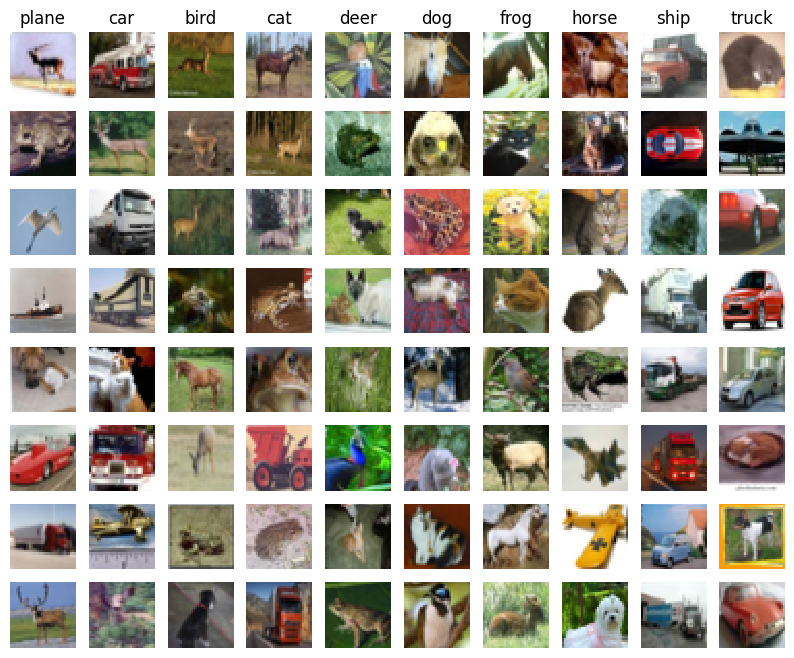

In [19]:
# 通过可视化错误分类的图片，可以帮助我们理解算法的工作方式。
# 在这个可视化中，我们展示了被当前系统错误分类的图片。
# 第一列展示了被系统标记为“plane”但真实标签不是“plane”的图片。

examples_per_class = 8
classes = ["plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
for cls, cls_name in enumerate(classes):
    idxs = np.where((y_test != cls) & (y_test_pred == cls))[0]
    idxs = np.random.choice(idxs, examples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt.subplot(examples_per_class, len(classes), i * len(classes) + cls + 1)
        plt.imshow(X_test[idx].astype("uint8"))
        plt.axis("off")
        if i == 0:
            plt.title(cls_name)
plt.show()

### 内嵌问题 1：
<details><summary>Inline question 1:</summary>
Describe the misclassification results that you see. Do they make sense?
</details>
请描述你看到的错误分类结果。它们合理吗？

$\color{blue}{\textit 你的答案：}$ 
这些错误分类的结果在一定程度上是合理的，模型容易将具有相似背景或整体颜色相似的物体归为一类。例如有着大面积蓝色背景的小鸟可能会被误分类为飞机或船。
HOG 特征主要捕捉边缘和局部形状，猫和狗在轮廓和边缘特征上非常相似，模型很难将它们区分开来。




## 在图像特征上训练神经网络
<details><summary>Neural Network on image features</summary>
Earlier in this assigment we saw that training a two-layer neural network on raw pixels achieved better classification performance than linear classifiers on raw pixels. In this notebook we have seen that linear classifiers on image features outperform linear classifiers on raw pixels.

For completeness, we should also try training a neural network on image features. This approach should outperform all previous approaches: you should easily be able to achieve over 55% classification accuracy on the test set; our best model achieves about 60% classification accuracy.
</details>
在本作业的前面，我们看到在原始像素上训练两层神经网络比线性分类器效果更好。在本笔记本中，我们也看到在图像特征上训练线性分类器比在原始像素上效果更好。

为了完整性，我们还应该尝试在图像特征上训练神经网络。这种方法应该优于之前所有方法：你应该可以轻松在测试集上达到 55% 以上的准确率，我们的最佳模型能达到约 60%。

In [20]:
# 预处理：移除偏置维度
# 请确保只运行一次本单元格
print(X_train_feats.shape)
X_train_feats = X_train_feats[:, :-1]
X_val_feats = X_val_feats[:, :-1]
X_test_feats = X_test_feats[:, :-1]

print(X_train_feats.shape)

(49000, 170)
(49000, 169)


In [21]:
from cs231n.classifiers.fc_net import TwoLayerNet
from cs231n.solver import Solver

input_dim = X_train_feats.shape[1]
hidden_dim = 500
num_classes = 10

data = {
    "X_train": X_train_feats,
    "y_train": y_train,
    "X_val": X_val_feats,
    "y_val": y_val,
    "X_test": X_test_feats,
    "y_test": y_test,
}

net = TwoLayerNet(input_dim, hidden_dim, num_classes)
best_net = None

################################################################################
# TODO:                                                                        #
# 训练一个两层神经网络用于图像特征。你可以像之前一样交叉验证参数。                        #
# Train a two-layer neural network on image features. You may want to          #
# 将你的最佳模型保存在 best_net 变量中。                                            #
# cross-validate various parameters as in previous sections. Store your best    #
#                                                                               #
# model in the best_net variable.                                               #
################################################################################
import itertools

# 定义超参数搜索空间
learning_rates = [1e-1, 5e-1, 1.0]      # 神经网络对于提取好的特征通常需要较大的学习率
regularization_strengths = [1e-4, 1e-3, 1e-2]
hidden_sizes = [500]                    # 题干提到了500，我们可以保持或略微调整，这里保持固定以节省时间

best_val = -1
results = {}

for lr, reg, hidden_size in itertools.product(learning_rates, regularization_strengths, hidden_sizes):
    # 初始化网络
    net = TwoLayerNet(input_dim, hidden_size, num_classes)
    

    solver = Solver(net, data,
                    update_rule='sgd',
                    optim_config={
                      'learning_rate': lr,
                    },
                    lr_decay=0.95,
                    num_epochs=15, batch_size=200,
                    print_every=1000) 
    
    # 额外给网络加个 reg 属性的可能情况，在你的 TwoLayerNet 具体实现里
    net.reg = reg
    
    solver.train()
    
    # 获取验证集上的最好准确率
    val_acc = solver.best_val_acc
    results[(lr, reg, hidden_size)] = val_acc
    
    print(f"lr: {lr}, reg: {reg}, hidden: {hidden_size} -> val_acc: {val_acc}")
    
    if val_acc > best_val:
        best_val = val_acc
        best_net = net

print(f"Best validation accuracy: {best_val}")

(Iteration 1 / 3675) loss: 2.302573
(Epoch 0 / 15) train acc: 0.110000; val_acc: 0.102000
(Epoch 1 / 15) train acc: 0.440000; val_acc: 0.420000
(Epoch 2 / 15) train acc: 0.491000; val_acc: 0.509000
(Epoch 3 / 15) train acc: 0.559000; val_acc: 0.519000
(Epoch 4 / 15) train acc: 0.541000; val_acc: 0.537000
(Iteration 1001 / 3675) loss: 1.339338
(Epoch 5 / 15) train acc: 0.536000; val_acc: 0.539000
(Epoch 6 / 15) train acc: 0.556000; val_acc: 0.556000
(Epoch 7 / 15) train acc: 0.547000; val_acc: 0.554000
(Epoch 8 / 15) train acc: 0.597000; val_acc: 0.561000
(Iteration 2001 / 3675) loss: 1.198043
(Epoch 9 / 15) train acc: 0.581000; val_acc: 0.567000
(Epoch 10 / 15) train acc: 0.600000; val_acc: 0.567000
(Epoch 11 / 15) train acc: 0.644000; val_acc: 0.583000
(Epoch 12 / 15) train acc: 0.594000; val_acc: 0.582000
(Iteration 3001 / 3675) loss: 1.104891
(Epoch 13 / 15) train acc: 0.595000; val_acc: 0.585000
(Epoch 14 / 15) train acc: 0.605000; val_acc: 0.588000
(Epoch 15 / 15) train acc: 0.614

In [22]:
# 在测试集上运行你的最佳神经网络分类器。你应该能达到 58% 以上的准确率。
# 通过仔细调参，也有可能超过 60%。

y_test_pred = np.argmax(best_net.loss(data["X_test"]), axis=1)
test_acc = (y_test_pred == data["y_test"]).mean()
print(test_acc)

0.582


In [23]:
# 保存最佳模型
best_net.save("best_two_layer_net_features.npy")

best_two_layer_net_features.npy saved.
